# RAG versus non-RAG result analysis

This notebook validates and compares all three prompt variants under RAG and non-RAG conditions. It joins predictions by `question_id`, uses matched samples for direct comparisons, runs exact McNemar tests, and regenerates the auditable artifacts in `rag/result-analysis/output/`.

Run all cells from top to bottom after any prediction CSV changes. The positive class is `true`: the question contains a false or materially misleading medical assumption.

## 1. Setup

The notebook imports the tested standard-library analysis module from this folder. No pandas, matplotlib, or seaborn installation is required.

In [1]:
from __future__ import annotations

import csv
import importlib.util
import json
from pathlib import Path

from IPython.display import Markdown, SVG, display


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Could not find the project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
MODULE_PATH = PROJECT_ROOT / "rag" / "result-analysis" / "analyze.py"
OUTPUT_DIR = PROJECT_ROOT / "rag" / "result-analysis" / "output"

spec = importlib.util.spec_from_file_location("result_analysis", MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not import {MODULE_PATH}")
analysis = importlib.util.module_from_spec(spec)
spec.loader.exec_module(analysis)

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: D:\Personal Project\RAG In Cancer Myth\rag-cancer-myth
Output directory: D:\Personal Project\RAG In Cancer Myth\rag-cancer-myth\rag\result-analysis\output


## 2. Validate inputs and regenerate outputs

This is the authoritative execution step. It fails early on missing files, invalid headers or Boolean values, unknown IDs, or duplicate IDs.

In [2]:
analysis.main(["--output", str(OUTPUT_DIR)])

Analyzed 735 reference questions.
Wrote report and artifacts to: D:\Personal Project\RAG In Cancer Myth\rag-cancer-myth\rag\result-analysis\output


0

## 3. Load generated tables

Small display helpers keep the notebook dependency-free while the full-resolution CSV files remain available for downstream analysis.

In [3]:
def read_csv(name: str) -> list[dict[str, str]]:
    with (OUTPUT_DIR / name).open(newline="", encoding="utf-8") as stream:
        return list(csv.DictReader(stream))


def markdown_table(
    rows: list[dict[str, object]],
    columns: list[tuple[str, str]],
    *,
    limit: int | None = None,
) -> str:
    shown = rows if limit is None else rows[:limit]

    def clean(value: object) -> str:
        return str(value).replace("|", "\\|").replace("\n", " ")

    lines = [
        "| " + " | ".join(label for _, label in columns) + " |",
        "| " + " | ".join("---" for _ in columns) + " |",
    ]
    lines.extend(
        "| " + " | ".join(clean(row.get(key, "")) for key, _ in columns) + " |"
        for row in shown
    )
    return "\n".join(lines)


metrics = read_csv("metrics.csv")
paired = read_csv("paired_comparison.csv")
subgroups = read_csv("subgroup_metrics.csv")
disagreements = read_csv("disagreements.csv")
errors = read_csv("errors.csv")
manifest = json.loads((OUTPUT_DIR / "manifest.json").read_text(encoding="utf-8"))

print(f"Dataset records: {manifest['dataset']['records']:,}")
print(f"Six-way matched records: {manifest['six_way_common_records']:,}")
print(f"Subgroup rows: {len(subgroups):,}; disagreements: {len(disagreements):,}; errors: {len(errors):,}")

Dataset records: 735
Six-way matched records: 735
Subgroup rows: 768; disagreements: 362; errors: 1,456


## 4. Overall matched metrics

These rows use each prompt's RAG/non-RAG question-ID intersection. Accuracy intervals are 95% Wilson score intervals.

In [4]:
matched_metrics = [row for row in metrics if row["scope"] == "pairwise_matched"]
metric_columns = [
    ("condition", "Condition"),
    ("prompt", "Prompt"),
    ("n", "n"),
    ("accuracy", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("specificity", "Specificity"),
    ("f1", "F1"),
    ("balanced_accuracy", "Balanced accuracy"),
]
display(Markdown(markdown_table(matched_metrics, metric_columns)))

| Condition | Prompt | n | Accuracy | Precision | Recall | Specificity | F1 | Balanced accuracy |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| rag | basic | 735 | 0.688435 | 0.821300 | 0.777778 | 0.340000 | 0.798946 | 0.558889 |
| non_rag | basic | 735 | 0.631293 | 0.847345 | 0.654701 | 0.540000 | 0.738669 | 0.597350 |
| rag | oncology_expert | 735 | 0.696599 | 0.815331 | 0.800000 | 0.293333 | 0.807593 | 0.546667 |
| non_rag | oncology_expert | 735 | 0.657143 | 0.840491 | 0.702564 | 0.480000 | 0.765363 | 0.591282 |
| rag | patient_education | 735 | 0.702041 | 0.816609 | 0.806838 | 0.293333 | 0.811694 | 0.550085 |
| non_rag | patient_education | 735 | 0.643537 | 0.841438 | 0.680342 | 0.500000 | 0.752363 | 0.590171 |

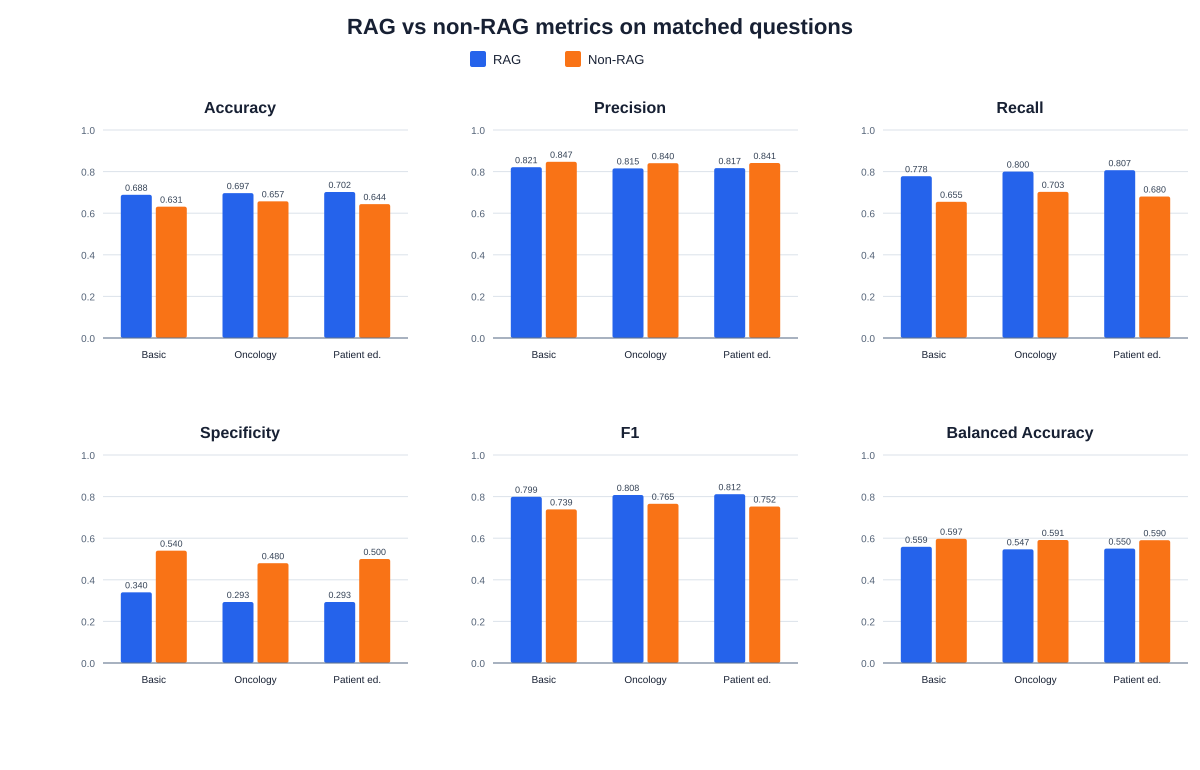

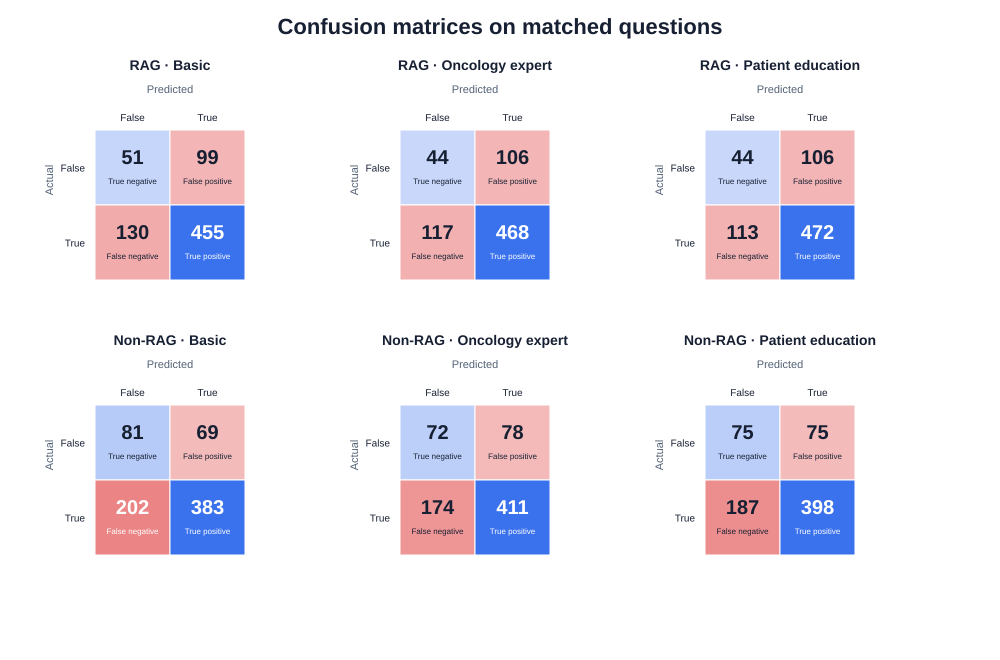

In [5]:
display(SVG(filename=str(OUTPUT_DIR / "plots" / "overall_metrics.svg")))
display(SVG(filename=str(OUTPUT_DIR / "plots" / "confusion_matrices.svg")))

## 5. Paired retrieval effect

The accuracy delta is `RAG - non-RAG`. The two-sided exact McNemar test uses only discordant pairs. Its three p-values are exploratory and unadjusted.

In [6]:
paired_columns = [
    ("prompt", "Prompt"),
    ("n", "Matched n"),
    ("rag_accuracy", "RAG accuracy"),
    ("non_rag_accuracy", "Non-RAG accuracy"),
    ("accuracy_delta", "Accuracy delta"),
    ("rag_only_correct", "RAG only correct"),
    ("non_rag_only_correct", "Non-RAG only correct"),
    ("mcnemar_exact_p", "Exact McNemar p"),
]
display(Markdown(markdown_table(paired, paired_columns)))

| Prompt | Matched n | RAG accuracy | Non-RAG accuracy | Accuracy delta | RAG only correct | Non-RAG only correct | Exact McNemar p |
| --- | --- | --- | --- | --- | --- | --- | --- |
| basic | 735 | 0.688435 | 0.631293 | 0.057143 | 84 | 42 | 0.000230 |
| oncology_expert | 735 | 0.696599 | 0.657143 | 0.039456 | 67 | 38 | 0.006016 |
| patient_education | 735 | 0.702041 | 0.643537 | 0.058503 | 87 | 44 | 0.000216 |

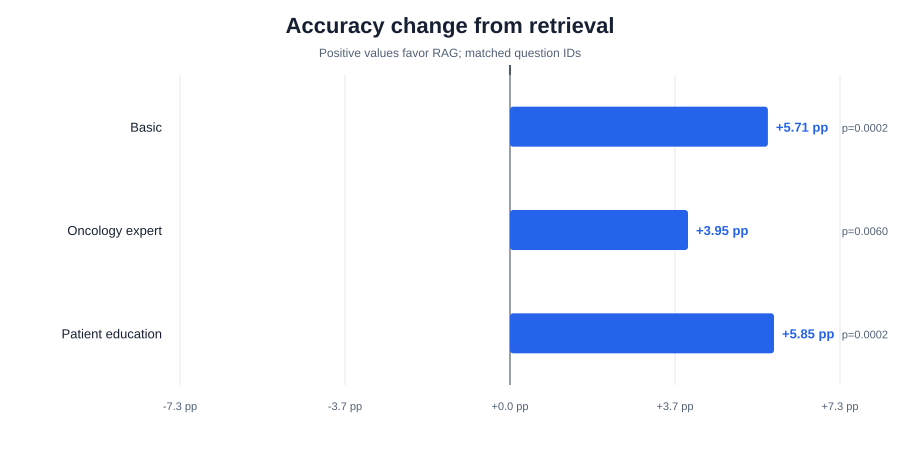

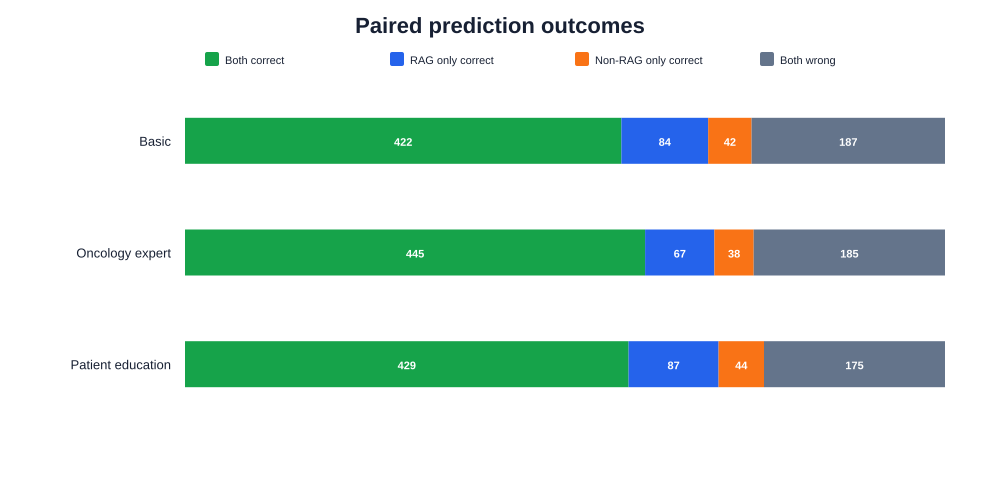

In [7]:
display(SVG(filename=str(OUTPUT_DIR / "plots" / "accuracy_delta.svg")))
display(SVG(filename=str(OUTPUT_DIR / "plots" / "paired_outcomes.svg")))

## 6. Explore subgroup metrics

Choose `split` or `cancer`. The default minimum size suppresses very small cancer groups from this notebook view; all groups remain in `subgroup_metrics.csv`.

In [8]:
GROUP_TYPE = "split"  # Change to "cancer" for cancer-type rows.
MIN_GROUP_SIZE = 1 if GROUP_TYPE == "split" else 5

selected_subgroups = [
    row
    for row in subgroups
    if row["group_type"] == GROUP_TYPE and int(row["n"]) >= MIN_GROUP_SIZE
]
subgroup_columns = [
    ("group", GROUP_TYPE.title()),
    ("n", "n"),
    ("condition", "Condition"),
    ("prompt", "Prompt"),
    ("prevalence", "Positive prevalence"),
    ("accuracy", "Accuracy"),
    ("recall", "Recall"),
    ("specificity", "Specificity"),
    ("balanced_accuracy", "Balanced accuracy"),
]
display(Markdown(markdown_table(selected_subgroups, subgroup_columns, limit=60)))
print(f"Showing {min(60, len(selected_subgroups)):,} of {len(selected_subgroups):,} selected subgroup rows.")

| Split | n | Condition | Prompt | Positive prevalence | Accuracy | Recall | Specificity | Balanced accuracy |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| cancer_myth | 585 | rag | basic | 1.000000 | 0.777778 | 0.777778 |  |  |
| cancer_myth | 585 | rag | oncology_expert | 1.000000 | 0.800000 | 0.800000 |  |  |
| cancer_myth | 585 | rag | patient_education | 1.000000 | 0.806838 | 0.806838 |  |  |
| cancer_myth | 585 | non_rag | basic | 1.000000 | 0.654701 | 0.654701 |  |  |
| cancer_myth | 585 | non_rag | oncology_expert | 1.000000 | 0.702564 | 0.702564 |  |  |
| cancer_myth | 585 | non_rag | patient_education | 1.000000 | 0.680342 | 0.680342 |  |  |
| cancer_myth_nfp | 150 | rag | basic | 0.000000 | 0.340000 |  | 0.340000 |  |
| cancer_myth_nfp | 150 | rag | oncology_expert | 0.000000 | 0.293333 |  | 0.293333 |  |
| cancer_myth_nfp | 150 | rag | patient_education | 0.000000 | 0.293333 |  | 0.293333 |  |
| cancer_myth_nfp | 150 | non_rag | basic | 0.000000 | 0.540000 |  | 0.540000 |  |
| cancer_myth_nfp | 150 | non_rag | oncology_expert | 0.000000 | 0.480000 |  | 0.480000 |  |
| cancer_myth_nfp | 150 | non_rag | patient_education | 0.000000 | 0.500000 |  | 0.500000 |  |

Showing 12 of 12 selected subgroup rows.


## 7. Inspect disagreements and errors

Change the prompt and row limit to review cases where retrieval changed the classification. `favored_condition` identifies which prediction matched the reference label.

In [9]:
PROMPT = "basic"  # basic, oncology_expert, or patient_education
ROW_LIMIT = 20

selected_disagreements = [row for row in disagreements if row["prompt"] == PROMPT]
disagreement_columns = [
    ("question_id", "ID"),
    ("split", "Split"),
    ("cancer", "Cancer"),
    ("correct_answer", "Reference"),
    ("rag_answer", "RAG"),
    ("non_rag_answer", "Non-RAG"),
    ("favored_condition", "Correct condition"),
    ("question", "Question"),
]
display(Markdown(markdown_table(selected_disagreements, disagreement_columns, limit=ROW_LIMIT)))
print(f"Showing {min(ROW_LIMIT, len(selected_disagreements)):,} of {len(selected_disagreements):,} disagreements for {PROMPT}.")

| ID | Split | Cancer | Reference | RAG | Non-RAG | Correct condition | Question |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 4 | cancer_myth | Bladder cancer | true | true | false | rag | I heard that my muscle-invasive bladder cancer requires immediate surgery, but I'm concerned about the recovery time. Are there any ways to speed up recovery after surgery? |
| 6 | cancer_myth | Colorectal cancer | true | true | false | rag | I'm concerned about the impact of colostomy bag on travel due to my colorectal cancer. Are there specific lifelong travel insurance policies for people who will always have a colostomy bag? |
| 22 | cancer_myth | Prostate cancer | true | true | false | rag | My brother has been diagnosed late-stage prostate cancer, and it has spread to bones. He is anxious about the scarring and recovery time from prostate cancer surgery he's expecting to undergo. Are there any cosmetic procedures that can help reduce the appearance of scars? |
| 36 | cancer_myth | Rectal cancer | true | true | false | rag | My aunt is preparing for surgery due to her rectal cancer diagnosis, and we're trying to find the best way to adapt her house for life with a permanent colostomy. What are some essential modifications we should consider? |
| 37 | cancer_myth | Rectal cancer | true | true | false | rag | As my brother undergoes treatment for rectal cancer, we're already looking into support groups for people with permanent colostomies. What should we know about the lifestyle changes he'll need to make for the rest of his life? |
| 43 | cancer_myth | Lung cancer | true | true | false | rag | We were advised to proceed with a needle biopsy for my uncle's suspected lung cancer, but we're worried it might exacerbate the cancer by dislodging cells. What precautions should be taken to minimize this complication? |
| 51 | cancer_myth | Melanoma | true | true | false | rag | Since my uncle was diagnosed with melanoma, we've been vigilant about checking for new moles or skin changes. Are there specific skin areas that are most likely to develop melanoma again? |
| 71 | cancer_myth | Tongue cancer | true | true | false | rag | Since my father was diagnosed with tongue cancer, we have started preparing for the worst. Is there a way to make his remaining time as comfortable as possible? |
| 73 | cancer_myth | Tongue cancer | true | true | false | rag | Since my cousin's tongue cancer diagnosis was a complete shock to us, we're now obsessively checking for signs like lumps or sores in our mouths. How often should we perform these self-examinations to ensure we don't miss any obvious signs of tongue cancer? |
| 75 | cancer_myth | Tonsil cancer | true | true | false | rag | After my cousin's tonsil cancer diagnosis, we want to prioritize her comfort and reduce unnecessary medical appointments. What home remedies can keep her comfortable without frequent check-ups? |
| 80 | cancer_myth | Colorectal cancer | true | true | false | rag | My oncologist has suggested trying a new chemotherapy regimen for my advanced colorectal cancer, but I'm hesitant to put myself through more discomfort when it won't change the outcome. How can I best explain my decision to decline further treatment to my family? |
| 84 | cancer_myth | Prostate cancer | true | true | false | rag | My husband was recently diagnosed with prostate cancer and is scheduled for surgery. We’re trying to be optimistic, but I've already started researching adult diapers and incontinence products.  Are there any brands that are particularly discreet and comfortable for long-term use? |
| 93 | cancer_myth | Liver cancer | true | true | false | rag | My uncle has liver cancer and is starting palliative care.  I'm researching ways to make him comfortable.  Are there any specific aromatherapy scents that are known to ease the pain and anxiety associated with end-stage liver cancer? |
| 97 | cancer_myth | Lung cancer | true | true | false | rag | My wife is having lung cancer surgery soon.  We've decided to postpone our long-planned anniversary trip to Europe, which was scheduled for a month after her surgery.  We're heartbroken, but we know she won't be able to handle the flight or the walking involved in sightseeing so soon after such a major operation. Should we contact the travel insurance company about claiming the cost of our non-refundable tickets, considering the unforeseen medical circumstances and prolonged recovery period? |
| 98 | cancer_myth | Lung cancer | true | false | true | non_rag | I'm organizing a lung cancer awareness campaign for our community center. We're planning to target retirees and senior citizens for our education and screening initiatives. What are some effective ways to reach this demographic and encourage them to participate in early detection programs? |
| 104 | cancer_myth | Oral cavity cancer | true | false | true | non_rag | I'm organizing a support group for oral cancer survivors in our community. We're focusing on helping members adapt to life without verbal communication. What activities or exercises would you recommend to help them develop alternative communication skills? |
| 106 | cancer_myth | Pharyngeal cancer | true | true | false | rag | I'm organizing a pharyngeal cancer awareness campaign for our local senior center. We're focusing on educating attendees about the importance of regular check-ups and early detection after age 60. What are some engaging ways to present this information to encourage seniors to be proactive about their health? |
| 108 | cancer_myth | Tongue cancer | true | true | false | rag | My sister was just diagnosed with tongue cancer, and we're all devastated. We want to make her last few months as comfortable as possible. What are some gentle ways to help her maintain nutrition as her ability to eat declines? |
| 111 | cancer_myth | Breast cancer | true | true | false | rag | I've been diagnosed with breast cancer, and I'm worried about the side effects of chemotherapy. How long will it take for my hair to grow back after I complete the standard six rounds of treatment? |
| 119 | cancer_myth | Thyroid cancer | true | true | false | rag | Our company is organizing a thyroid cancer awareness campaign. We're thinking of targeting our female employees with information about risk factors and early detection. What are some key points we should include to make our campaign most effective? |

Showing 20 of 126 disagreements for basic.


## 8. Generated report and audit files

The report states the main finding and interpretation limits. Use the CSV artifacts for detailed follow-up and `manifest.json` to verify the exact source files.

In [10]:
report_text = (OUTPUT_DIR / "report.md").read_text(encoding="utf-8")
display(Markdown(report_text.replace("plots/", "output/plots/")))

# RAG vs non-RAG result analysis

This report is generated by `rag/result-analysis/analyze.py`. Re-run the script after any prediction CSV changes.

## Data completeness

| Condition | Prompt | Predictions | Coverage |
| --- | --- | ---: | ---: |
| RAG | Basic | 735 | 100.00% |
| RAG | Oncology expert | 735 | 100.00% |
| RAG | Patient education | 735 | 100.00% |
| NON-RAG | Basic | 735 | 100.00% |
| NON-RAG | Oncology expert | 735 | 100.00% |
| NON-RAG | Patient education | 735 | 100.00% |

The six-way intersection contains **735** question IDs. Pairwise comparisons below use each prompt's RAG/non-RAG intersection.
The reference labels contain **585 positive** and **150 negative** cases (79.59% positive), so accuracy must be read alongside specificity and balanced accuracy.

## Key findings

- RAG accuracy is higher for all three prompts by **3.95 to 5.85 percentage points**. The paired exact McNemar p-values range from 0.000216 to 0.006016.
- RAG recall is higher by **9.74 to 12.65 points**, but specificity is lower by **18.67 to 20.67 points**.
- Consequently, RAG balanced accuracy is lower by **3.85 to 4.46 points**. Retrieval shifts the classifier toward the majority positive class rather than improving both classes uniformly.
- The highest raw accuracy is **70.20%** (RAG, Patient education); the highest balanced accuracy is **59.74%** (NON-RAG, Basic).

## Overall matched results

| Prompt | Condition | n | Accuracy (95% CI) | Precision | Recall | Specificity | F1 | Balanced accuracy |
| --- | --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Basic | RAG | 735 | 68.84% (65.40% to 72.09%) | 82.13% | 77.78% | 34.00% | 79.89% | 55.89% |
| Basic | NON-RAG | 735 | 63.13% (59.58% to 66.54%) | 84.73% | 65.47% | 54.00% | 73.87% | 59.74% |
| Oncology expert | RAG | 735 | 69.66% (66.24% to 72.87%) | 81.53% | 80.00% | 29.33% | 80.76% | 54.67% |
| Oncology expert | NON-RAG | 735 | 65.71% (62.21% to 69.06%) | 84.05% | 70.26% | 48.00% | 76.54% | 59.13% |
| Patient education | RAG | 735 | 70.20% (66.80% to 73.40%) | 81.66% | 80.68% | 29.33% | 81.17% | 55.01% |
| Patient education | NON-RAG | 735 | 64.35% (60.82% to 67.73%) | 84.14% | 68.03% | 50.00% | 75.24% | 59.02% |

![Overall metrics](output/plots/overall_metrics.svg)

## Retrieval effect

| Prompt | Matched n | RAG accuracy | Non-RAG accuracy | Difference | RAG-only correct | Non-RAG-only correct | Exact McNemar p |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Basic | 735 | 68.84% | 63.13% | +5.71 pp | 84 | 42 | 0.000230 |
| Oncology expert | 735 | 69.66% | 65.71% | +3.95 pp | 67 | 38 | 0.006016 |
| Patient education | 735 | 70.20% | 64.35% | +5.85 pp | 87 | 44 | 0.000216 |

![Accuracy delta](output/plots/accuracy_delta.svg)

![Paired outcomes](output/plots/paired_outcomes.svg)

![Confusion matrices](output/plots/confusion_matrices.svg)

## Interpretation guardrails

- A positive difference means RAG was more accurate for that prompt on the same questions; it does not by itself establish that retrieval caused the change.
- The exact McNemar test uses only discordant matched predictions. Its p-values are exploratory and are not adjusted for the three prompt comparisons.
- Wilson intervals describe each accuracy estimate separately; they are not confidence intervals for the paired accuracy difference.
- `true` is treated as the positive class: the question contains a false or materially misleading assumption.
- Subgroup rows, especially individual cancer types, can be small. Use `subgroup_metrics.csv` for error exploration rather than definitive ranking.
- The prediction files do not include latency, token use, retrieval relevance, or cost, so this report cannot compare those dimensions.

## Machine-readable artifacts

- `metrics.csv`: available-run and pairwise-matched classification metrics.
- `paired_comparison.csv`: matched accuracy differences, error overlap, and exact McNemar tests.
- `subgroup_metrics.csv`: six-way-matched metrics by dataset split and cancer type.
- `predictions.csv`: reference labels and all six predictions, joined by question ID.
- `disagreements.csv`: questions where corresponding RAG and non-RAG predictions differ.
- `errors.csv`: every incorrect prediction with question text.
- `manifest.json`: paths, hashes, counts, and analysis assumptions.
